# F1 Race Data Analysis
**Martin Adebayo · Magd Aref · Johann Cubillo**

Data: [Formula 1 Race Dataset (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)

---
## Table of contents
1. [Setup & data loading](#setup)
2. [Data cleaning](#cleaning)
3. [Pit stop strategy](#pit-stops)
4. [Circuit clustering](#clustering)
5. [Grid vs finishing position](#grid-finish)
6. [Race result predictor (ML)](#ml)
7. [Constructor standings](#constructors)
8. [Driver careers](#careers)
9. [DNF breakdown](#dnf)
10. [Summary](#summary)


---
## 1. Setup & data loading <a id='setup'></a>

The dataset comes from Kaggle and mirrors the official F1 records going back to the very first World Championship race in 1950. It is split across 14 CSV files — one per topic (races, drivers, lap times, etc.) — that are linked together using shared ID columns, much like tables in a database. The first step is loading all of them into memory and converting any columns that should be numbers (some were stored as text in the original export).

**To run this notebook you need to download the dataset first.** The cell below will download it automatically using the Kaggle API if you have your credentials set up. Alternatively, you can download the files manually from the link above and place all CSV files in the same folder as this notebook, then skip the download cell.


In [351]:
# Libraries 
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt 
import seaborn as sns             
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

# Load all CSVs (treat '\N' as NaN right away)
CSV_NULL = '\\N'
results       = pd.read_csv('results.csv',        na_values=CSV_NULL)
races         = pd.read_csv('races.csv',          na_values=CSV_NULL)
drivers       = pd.read_csv('drivers.csv',        na_values=CSV_NULL)
constructors  = pd.read_csv('constructors.csv',   na_values=CSV_NULL)
circuits      = pd.read_csv('circuits.csv',       na_values=CSV_NULL)
status        = pd.read_csv('status.csv',         na_values=CSV_NULL)
standings     = pd.read_csv('driver_standings.csv', na_values=CSV_NULL)
con_standings = pd.read_csv('constructor_standings.csv', na_values=CSV_NULL)
pit_stops     = pd.read_csv('pit_stops.csv',      na_values=CSV_NULL)
lap_times     = pd.read_csv('lap_times.csv',      na_values=CSV_NULL)

# Convert columns that should be numbers
for col in ['grid', 'positionOrder', 'points', 'laps']:
    results[col] = pd.to_numeric(results[col], errors='coerce')
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

# Remove duplicate rows (same driver in same race from pre-qualifying)
results = results.drop_duplicates(subset=['raceId', 'driverId'], keep='first')

print(f'results: {len(results):,} rows')
print(f'lap_times: {len(lap_times):,} rows')


results: 27,213 rows
lap_times: 618,766 rows


In [352]:
df = results.copy()

# Add year, round, and circuit information from the races table
df = df.merge(races[['raceId', 'year', 'round', 'circuitId']], on='raceId')

# Add driver name
df = df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
df['driver'] = df['forename'] + ' ' + df['surname']

# Add team (constructor) name
df = df.merge(constructors[['constructorId', 'name']], on='constructorId')

# Add retirement reason (status)
df = df.merge(status[['statusId', 'status']], on='statusId')

# Create a full-name column for the constructor
df = df.rename(columns={'name': 'team'})


# DNF = Did Not Finish. Cars that are "lapped" (+1 Lap etc.) did finish — only
# mechanical failures and crashes count as DNFs.
lapped   = df['status'].str.startswith('+')   # e.g. "+1 Lap"
finished = df['statusId'] == 1                 # "Finished"
df['dnf']    = (~(finished | lapped)).astype(int)   # 1 = retired, 0 = finished
df['win']    = (df['positionOrder'] == 1).astype(int)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# keep rows where the driver actually started from the grid
base = df[df['grid'] > 0].copy()
base['pos_change'] = base['grid'] - base['positionOrder']  # positive = gained places

print(f"Working table: {len(base):,} race starts")
print(base[['driver', 'team', 'year', 'grid', 'positionOrder', 'pos_change', 'dnf']].head())


Working table: 25,558 race starts
              driver        team  year  grid  positionOrder  pos_change  dnf
0     Lewis Hamilton     McLaren  2008   1.0              1         0.0    0
1      Nick Heidfeld  BMW Sauber  2008   5.0              2         3.0    0
2       Nico Rosberg    Williams  2008   7.0              3         4.0    0
3    Fernando Alonso     Renault  2008  11.0              4         7.0    0
4  Heikki Kovalainen     McLaren  2008   3.0              5        -2.0    0


---
## 2. Data cleaning <a id='cleaning'></a>

Before analysing anything we need to make sure the data is trustworthy. Three problems needed fixing: missing values in key columns, extreme lap times caused by red-flag stoppages, and rows with `grid = 0`, which represent drivers who started from the pit lane rather than the normal starting grid. Those pit-lane starts are excluded from any analysis that uses grid position, because their starting point is not comparable.


In [353]:
# Check for null values in key columns
print('Null values in results:')
for col in ['grid', 'positionOrder', 'points', 'laps']:
    n = results[col].isna().sum()
    print(f'  {col}: {n:,} nulls')

# Grid = 0 means pit lane start
grid_zero = len(results[results['grid'] == 0])
print(f'\nRows with grid = 0 (pit lane starts): {grid_zero:,}')


Null values in results:
  grid: 20 nulls
  positionOrder: 0 nulls
  points: 0 nulls
  laps: 0 nulls

Rows with grid = 0 (pit lane starts): 1,635


In [354]:
# Outlier removal: lap times slower than 150% of the race median are removed
min_lap = lap_times['milliseconds'].min() / 1000
max_lap = lap_times['milliseconds'].max() / 1000
slow_lap_count = (lap_times['milliseconds'] > 300_000).sum()

race_median = lap_times.groupby('raceId')['milliseconds'].median().rename('race_med')
lap_times = lap_times.drop(columns=['race_med'], errors='ignore').join(race_median, on='raceId')
lap_times = lap_times[
    lap_times['milliseconds'] < lap_times['race_med'] * 1.50
].copy()

removed_pct = (slow_lap_count / len(lap_times) * 100)
print(f'Lap time range: {min_lap:.1f}s – {max_lap:.1f}s')
print(f'Laps over 5 min: {slow_lap_count:,}')
print(f'Filtered out laps > 150% of race median. Kept: {len(lap_times):,} laps')


Lap time range: 55.4s – 7507.5s
Laps over 5 min: 710
Filtered out laps > 150% of race median. Kept: 606,268 laps


In [355]:
# Invalid rows — grid position = 0 means pit lane start
grid_zero = results[results['grid'] == 0]
print(f'Rows with grid = 0 (pit lane starts): {len(grid_zero):,}')
# These drivers started from the pit lane, not the normal grid.
print(grid_zero.merge(status[['statusId', 'status']], on='statusId').head())


Rows with grid = 0 (pit lane starts): 1,635
   resultId  raceId  driverId  constructorId  number  grid  position  \
0      2282     127        62             18    22.0   0.0       NaN   
1      2433     134        49             21    20.0   0.0       NaN   
2      2434     134        59             21    21.0   0.0       NaN   
3      2435     134        21             17     9.0   0.0       NaN   
4      2798     151        58             18    20.0   0.0       NaN   

  positionText  positionOrder  points  laps time  milliseconds  fastestLap  \
0            F             22     0.0     0  NaN           NaN         NaN   
1            F             20     0.0     0  NaN           NaN         NaN   
2            F             21     0.0     0  NaN           NaN         NaN   
3            F             22     0.0     0  NaN           NaN         NaN   
4            F             22     0.0     0  NaN           NaN         NaN   

   rank fastestLapTime  fastestLapSpeed  statusId     

---
## 3. Pit stop strategy <a id='pit-stops'></a>

**Question:** Does the number of pit stops affect how many places a driver gains or loses?

**Background — what is a pit stop?** During a race, tyre rubber wears down over many laps and the car gets slower. Teams call their driver into the pit lane to swap worn tyres for fresh ones. The stop itself costs about 20–25 seconds of race time, so teams must decide whether the speed gained from new tyres is worth the time lost standing still. This trade-off is called **pit stop strategy** and it is one of the biggest decisions a team makes during a race.

We use **position change** (starting grid − finishing position) as our outcome variable. A *positive* number means the driver moved forward (e.g. started 8th, finished 5th → +3). A *negative* number means they fell back. We compare three common strategies: 1-stop, 2-stop, and 3+ stops.


In [356]:
# Summarise pit stop data per driver per race
pit_stops['ms_num'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

pit_summary = (
    pit_stops
    .groupby(['raceId', 'driverId'])
    .agg(
        num_stops    = ('stop', 'count'),        # how many stops?
        avg_pit_ms   = ('ms_num', 'mean'),        # average stop duration
        first_stop_lap = ('lap', 'min')           # which lap was the first stop?
    )
    .reset_index()
)

# merge pit info onto our main table
df_pit = base.merge(pit_summary, on=['raceId', 'driverId'], how='left')

# Label each driver's strategy
df_pit['strategy'] = df_pit['num_stops'].map({
    1: '1-stop',
    2: '2-stop',
    3: '3+ stops'
})

# Strategy dristribution
ORDER    = ['1-stop', '2-stop', '3+ stops']
df_strat = df_pit[df_pit['strategy'].isin(ORDER)].copy()

print(df_strat['strategy'].value_counts(), '\n')
print(df_strat.groupby('strategy')['pos_change'].mean(), '\n')


strategy
2-stop      5022
1-stop      3716
3+ stops    1899
Name: count, dtype: int64 

strategy
1-stop      0.441335
2-stop      1.213262
3+ stops    0.586098
Name: pos_change, dtype: float64 



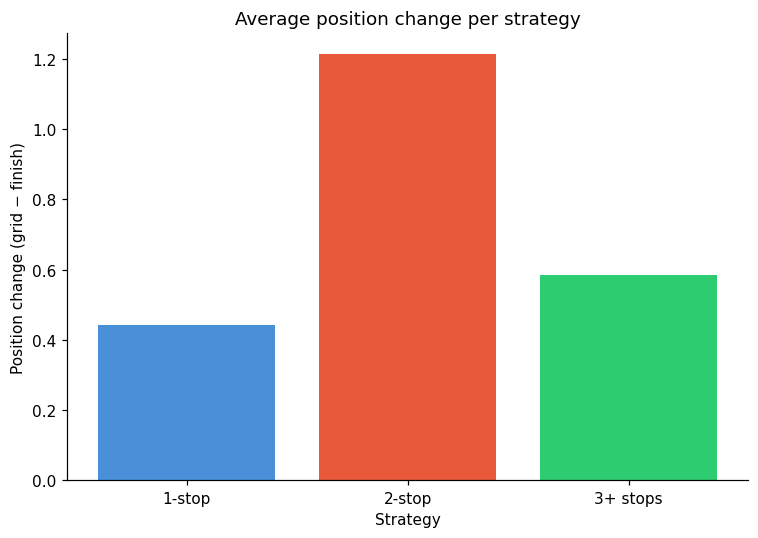

In [357]:
# Graph position change by strategy
avg = df_strat.groupby('strategy')['pos_change'].mean().reindex(ORDER)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(ORDER, avg, color=['#4A90D9', '#E8593C', '#2ECC71'])
ax.set_title('Average position change per strategy')
ax.set_xlabel('Strategy')
ax.set_ylabel('Position change (grid − finish)')
plt.tight_layout()
plt.show()


**Reading the chart:** The y-axis shows the *average* number of positions gained or lost. 

---
## 4. Circuit clustering <a id='clustering'></a>

**Question:** Can we group F1 circuits into types based on how races tend to play out?

**Background — why do circuits differ so much?** F1 visits tracks ranging from a narrow street circuit through Monaco's harbour (so tight that overtaking is nearly impossible) to wide, high-speed venues like Monza in Italy where cars can run wheel-to-wheel at 300 km/h. These physical differences show up in the data: narrow tracks see fewer overtakes and more accidents; high-speed tracks put more stress on tyres and engines. If we can identify circuit *types*, teams can tailor their strategy before the race weekend even begins.

**KMeans clustering** is an algorithm that finds groups of similar items automatically. We describe each circuit with three simple numbers and let the algorithm decide which circuits belong together. It does not know anything about the tracks in advance — it only sees the statistics.

**Features used (one row per circuit, averaged across all years):**
- `avg_stops` — average number of pit stops per driver (higher = more tyre wear or more strategy variation)
- `avg_pos_change` — average positions gained or lost per driver (higher = more overtaking, less predictable race)
- `dnf_rate` — share of drivers who did not finish (**DNF = Did Not Finish**, i.e. the car broke or crashed before the end)


In [358]:
# Average pit stops per driver per circuit
pit_per_circuit = (
    pit_stops
    .merge(races[['raceId', 'circuitId']], on='raceId')
    .groupby('circuitId')['stop']
    .mean()
    .rename('avg_stops')
    .reset_index()
)

# Average position change & DNF rate per circuit
race_stats = (
    base
    .groupby('circuitId')
    .agg(
        avg_pos_change=('pos_change', 'mean'),
        dnf_rate=('dnf', 'mean')
    )
    .reset_index()
)

# Merge into one table
circ_feats = (
    circuits[['circuitId', 'name']]
    .merge(pit_per_circuit, on='circuitId', how='left')
    .merge(race_stats,      on='circuitId', how='left')
    .dropna()
)

FEATURES = ['avg_stops', 'avg_pos_change', 'dnf_rate']
print(f'Circuits with enough data: {len(circ_feats)}')
print(circ_feats[FEATURES].describe().round(3))


Circuits with enough data: 43
       avg_stops  avg_pos_change  dnf_rate
count     43.000          43.000    43.000
mean       1.667          -0.016     0.319
std        0.304           0.055     0.136
min        1.156          -0.206     0.050
25%        1.526          -0.018     0.175
50%        1.683           0.000     0.360
75%        1.760           0.004     0.441
max        3.015           0.064     0.585


In [359]:
# Fit the final model (k=2)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale features so each one carries equal weight
X = StandardScaler().fit_transform(circ_feats[FEATURES].to_numpy())

K_FINAL = 2
circ_feats['cluster'] = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10).fit_predict(X)


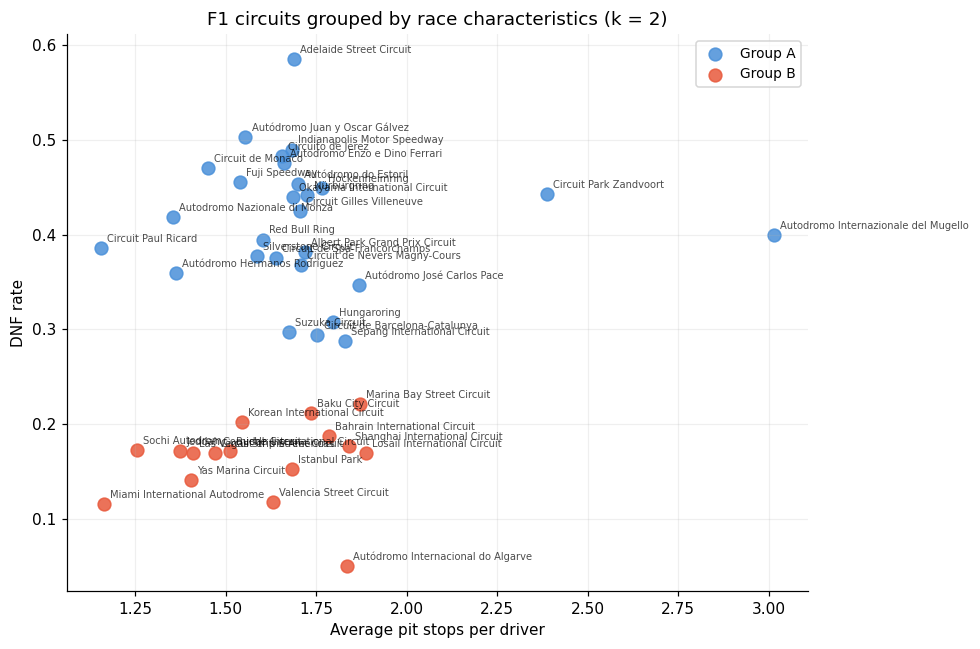

In [360]:
# Scatter: avg stops vs DNF rate
CLUSTER_NAMES = {0: 'Group A', 1: 'Group B'}
palette = ['#4A90D9', '#E8593C']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_FINAL):
    mask = circ_feats['cluster'] == c
    ax.scatter(
        circ_feats.loc[mask, 'avg_stops'],
        circ_feats.loc[mask, 'dnf_rate'],
        s=70, label=CLUSTER_NAMES[c], color=palette[c], alpha=0.85
    )
    # Label each point with the circuit name
    for _, row in circ_feats[mask].iterrows():
        ax.annotate(row['name'], (row['avg_stops'], row['dnf_rate']),
                    fontsize=6.5, alpha=0.7, xytext=(4, 4),
                    textcoords='offset points')

ax.set_xlabel('Average pit stops per driver')
ax.set_ylabel('DNF rate')
ax.set_title(f'F1 circuits grouped by race characteristics (k = {K_FINAL})')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 5. Grid position vs finishing position <a id='grid-finish'></a>

**Question:** How strongly does your qualifying position predict where you finish?

**Background — what is qualifying?** The day before the race, drivers compete in a separate session called **qualifying**, where each car goes flat-out for a single fast lap. The driver with the fastest time starts at the front of the grid (called **pole position**); the slowest starts at the back. The grid — the starting order — is therefore a measure of pure one-lap car speed on that day.

The race itself is a different challenge: it is much longer, tyres wear, pit stops happen, and faster cars can get stuck behind slower ones. The question is how much of the qualifying advantage survives to the finish. We use **Pearson correlation** to measure the relationship: a value of 1.0 would mean grid perfectly predicts finish every time; 0.0 would mean the result is completely random.

We also look at how this has changed across different **eras** of the sport, since rule changes over the decades have altered how easy it is to overtake.


In [361]:
# Correlation between grid and finishing position
# Interpretation: moderate positive correlation — starting further back
# is associated with finishing further back.
corr = base['grid'].corr(base['positionOrder'])

print("Correlation (grid vs finish):", round(corr, 3))

# Pole position win rate
pole_races  = base[base['grid'] == 1]
pole_win_rt = (pole_races['positionOrder'] == 1).mean() * 100
print("Pole position -> race win:", round(pole_win_rt, 1), "% of the time")

# Podium rates by grid band
print()
print("Podium (top 3) rate by starting position:")
for label, lo, hi in [('P1-3', 1, 3), ('P4-6', 4, 6),
                       ('P7-10', 7, 10), ('P11-15', 11, 15), ('P16+', 16, 40)]:
    sub  = base[(base['grid'] >= lo) & (base['grid'] <= hi)]
    rate = (sub['positionOrder'] <= 3).mean() * 100
    print("  Grid " + label + ": " + str(round(rate, 1)) + "%")


Correlation (grid vs finish): 0.45
Pole position -> race win: 43.4 % of the time

Podium (top 3) rate by starting position:
  Grid P1-3: 55.7%
  Grid P4-6: 25.7%
  Grid P7-10: 9.0%
  Grid P11-15: 2.9%
  Grid P16+: 0.8%


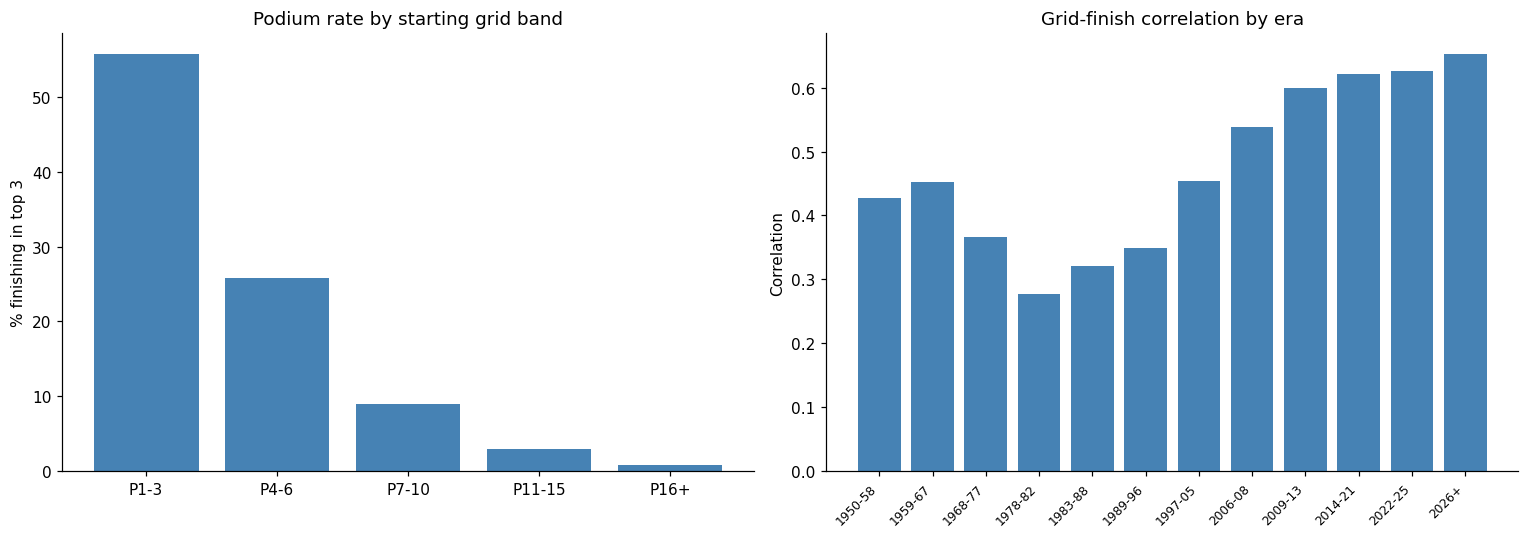

In [362]:
# Has the correlation changed over time?
era_bins   = [1949, 1958, 1966, 1976, 1981, 1987, 1995, 2004, 2007, 2012, 2020, 2024, 2030]
era_labels = ['1950-58', '1959-67', '1968-77', '1978-82', '1983-88',
              '1989-96', '1997-05', '2006-08', '2009-13', '2014-21', '2022-25', '2026+']
base['era'] = pd.cut(base['year'], bins=era_bins, labels=era_labels)

era_corr = (
    base.groupby('era', observed=True)
    .apply(lambda g: g['grid'].corr(g['positionOrder']))
    .reset_index()
)
era_corr.columns = ['era', 'correlation']

# Podium rate by grid band
bands  = ['P1-3', 'P4-6', 'P7-10', 'P11-15', 'P16+']
limits = [(1,3), (4,6), (7,10), (11,15), (16,40)]
rates  = [(base[(base['grid']>=lo)&(base['grid']<=hi)]['positionOrder']<=3).mean()*100
          for lo, hi in limits]

# Side-by-side display
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(bands, rates, color='steelblue')
ax1.set_title('Podium rate by starting grid band')
ax1.set_ylabel('% finishing in top 3')

ax2.bar(era_corr['era'], era_corr['correlation'], color='steelblue')
ax2.set_title('Grid-finish correlation by era')
ax2.set_ylabel('Correlation')
ax2.set_xticklabels(era_corr['era'], rotation=45, ha='right', fontsize=8)

fig.tight_layout()
plt.show()


---
## 6. Race result predictor (machine learning) <a id='ml'></a>

**Question:** Can we predict where a driver will finish using only information available before the race?

**Background — what is a Decision Tree?** A Decision Tree is one of the simplest machine learning models. It learns a series of yes/no rules from the training data — for example, 'if the driver starts in positions 1–3 AND their team scored more than 200 points last race, predict a podium finish'. We chose a Decision Tree because it is easy to explain and visualise, which is useful for understanding *why* the model makes the predictions it does.

We train a **Decision Tree** using these features:
- Grid position (qualifying result)
- Driver's past finishing position and championship points
- Constructor's past finishing position and championship points

**Design choice:** We train on races from 2001–2019 and test on races from 2020 onwards. This means the model never sees the test races during training.

> **Note:** The model struggles to beat the simple baseline of predicting a driver finishes where they qualified. This makes sense — F1 race outcomes depend heavily on in-race events (crashes, safety cars, weather) that no pre-race model can capture. Grid position alone is already a strong predictor.


In [363]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- Driver past performance ---
# Driver standings: use points from the previous race
drv = (standings
       .merge(races[['raceId', 'year', 'round']], on='raceId')
       .sort_values(['driverId', 'year', 'round']))
drv['driver_pts_before'] = drv.groupby(['driverId', 'year'])['points'].shift(1).fillna(0)

# Driver's finishing position in the previous race
pos = (base[['raceId', 'driverId', 'year', 'round', 'positionOrder']]
               .sort_values(['driverId', 'year', 'round']))
pos['finish_pos_before'] = pos.groupby('driverId')['positionOrder'].shift(1).fillna(10)

# --- Constructor past performance ---
# Constructor standings: use points from the previous race
con = (con_standings
       .merge(races[['raceId', 'year', 'round']], on='raceId')
       .sort_values(['constructorId', 'year', 'round']))
con['constructor_pts_before'] = con.groupby(['constructorId', 'year'])['points'].shift(1).fillna(0)

# Constructor's finishing position in the previous race
con_pos = (base[['raceId', 'constructorId', 'year', 'round', 'positionOrder']]
               .sort_values(['constructorId', 'year', 'round']))
con_pos['constructor_pos_before'] = con_pos.groupby('constructorId')['positionOrder'].shift(1).fillna(10)

# --- Merge all features onto base table ---
df_ml = (base
         .merge(drv[['raceId', 'driverId', 'driver_pts_before']],
                on=['raceId', 'driverId'], how='left')
         .merge(pos[['raceId', 'driverId', 'finish_pos_before']],
                on=['raceId', 'driverId'], how='left')
         .merge(con[['raceId', 'constructorId', 'constructor_pts_before']],
                on=['raceId', 'constructorId'], how='left')
         .merge(con_pos[['raceId', 'constructorId', 'constructor_pos_before']],
                on=['raceId', 'constructorId'], how='left'))

FEATURES = ['grid', 'driver_pts_before', 'finish_pos_before',
            'constructor_pts_before', 'constructor_pos_before']
df_ml = df_ml[FEATURES + ['positionOrder', 'year']].dropna()

# Bin finishing position into groups
def bin_position(p):
    if p == 1: return 'Win'
    if p <= 3: return 'Podium (P2-3)'
    if p <= 10: return 'Points'
    return 'Outside points'

df_ml['finish_bin'] = df_ml['positionOrder'].apply(bin_position)

# Train/test split by year
train = df_ml[(df_ml['year'] > 1999) & (df_ml['year'] < 2020)]
test  = df_ml[df_ml['year'] >= 2020]

X_train, y_train = train[FEATURES].to_numpy(), train['finish_bin'].to_numpy()
X_test,  y_test  = test[FEATURES].to_numpy(),  test['finish_bin'].to_numpy()

print("Training rows:", len(X_train), " (races 1999-2019)")
print("Test rows:",     len(X_test),  " (races 2020+)")
print("Features:", FEATURES)
print("\nClass distribution (test set):")
print(test['finish_bin'].value_counts())


Training rows: 15476  (races 1999-2019)
Test rows: 5171  (races 2020+)
Features: ['grid', 'driver_pts_before', 'finish_pos_before', 'constructor_pts_before', 'constructor_pos_before']

Class distribution (test set):
finish_bin
Outside points    2548
Points            1832
Podium (P2-3)      529
Win                262
Name: count, dtype: int64


In [364]:
# Fit decision tree
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)

# Baseline: predict based on grid position using same bins
baseline_preds = test['grid'].apply(bin_position).to_numpy()

# Built-in accuracy score
tree_acc = accuracy_score(y_test, tree_preds)
base_acc = accuracy_score(y_test, baseline_preds)

print(f"Decision Tree accuracy:  {tree_acc:.1%}")
print(f"Baseline (=grid) accuracy: {base_acc:.1%}")


Decision Tree accuracy:  69.2%
Baseline (=grid) accuracy: 66.7%


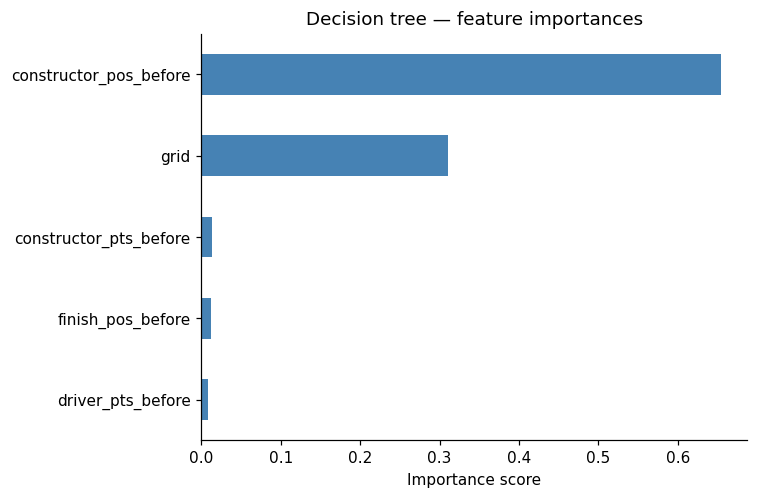

Most important features:
   constructor_pos_before : 0.654
   grid : 0.311
   constructor_pts_before : 0.014
   finish_pos_before : 0.013
   driver_pts_before : 0.008


In [365]:
# Which features matter most?
importances = pd.Series(tree.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind='barh', color='steelblue')
plt.title('Decision tree — feature importances')
plt.xlabel('Importance score')
plt.show()

print("Most important features:")
for feat, imp in importances.sort_values(ascending=False).items():
    print("  " , feat , ": " + str(round(imp, 3)))


---
## 7. Constructor standings over time <a id='constructors'></a>

**Background — what is a constructor?** In F1, a **constructor** (also called a team) designs and builds the car. Unlike most sports where athletes can move between clubs freely, the car itself is as important as the driver — arguably more so. Each season, both the drivers and the constructors compete for their own separate championships. The **Constructors' Championship** is awarded to the team that scores the most points across all their drivers combined over the season.

A visual of how the major constructor teams have risen and fallen since 1990. We show a line chart of final championship points per season for the six most historically prominent teams. Each line traces one team's trajectory; sharp rises reflect dominant seasons and sharp drops reflect rule changes, key personnel departures, or a rival team catching up.


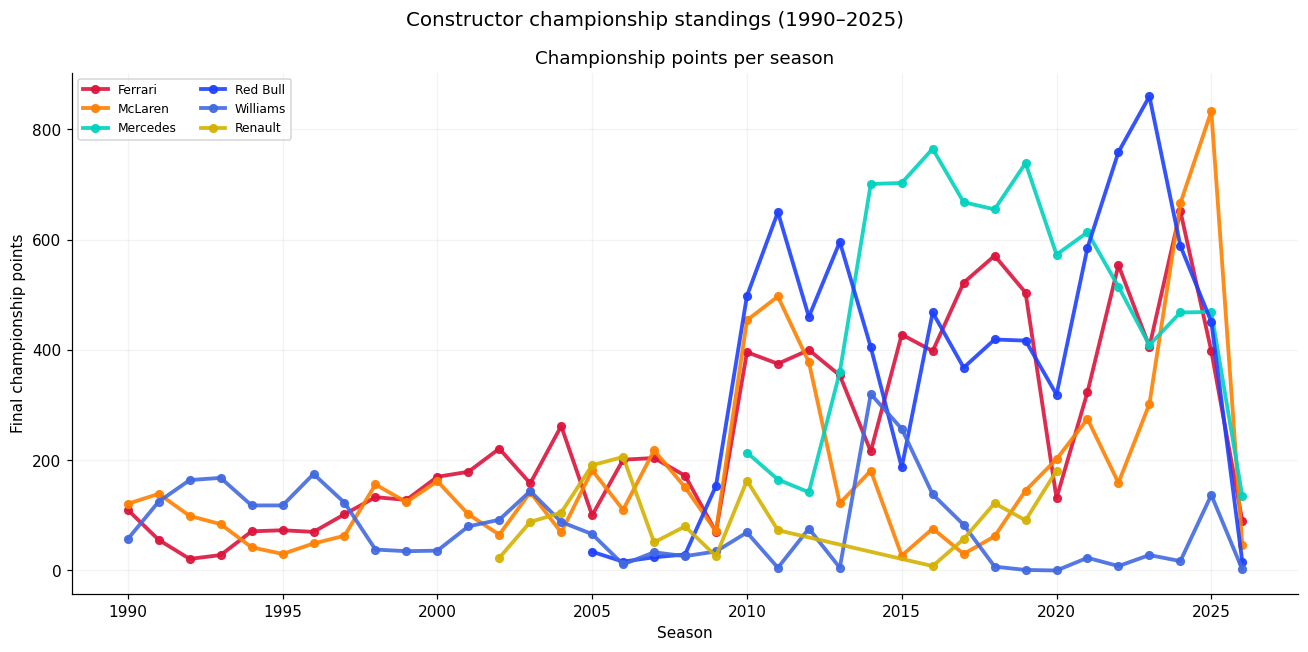

In [366]:
# Prepare constructor standings data
cs = (con_standings
      .merge(races[['raceId', 'year', 'round']], on='raceId')
      .merge(constructors[['constructorId', 'name']], on='constructorId'))
cs['points']   = pd.to_numeric(cs['points'],   errors='coerce')
cs['position'] = pd.to_numeric(cs['position'], errors='coerce')

# Final standings
final_cs = (cs[cs['year'] >= 1990]
            .sort_values('round')
            .groupby(['year', 'name'])
            .last()
            .reset_index())

# Focus on major teams
TEAMS = {
    'Ferrari':  '#DC143C', 'McLaren':  '#FF8000', 'Mercedes': '#00D2BE',
    'Red Bull': '#1E41FF', 'Williams': '#4169E1', 'Renault':  '#D4B200',
}
final_focus = final_cs[final_cs['name'].isin(TEAMS)][['year', 'name', 'points']]

# Line chart: championship points per season
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Constructor championship standings (1990–2025)', fontsize=13)

for team, color in TEAMS.items():
    td = final_focus[final_focus['name'] == team].sort_values('year')
    ax.plot(td['year'], td['points'], 'o-', label=team, color=color,
            linewidth=2.5, markersize=5, alpha=0.9)
ax.set_xlabel('Season')
ax.set_ylabel('Final championship points')
ax.set_title('Championship points per season')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


---
## 8. Driver career performance <a id='careers'></a>

**Question:** How do the greatest drivers of all time compare?

**Background — why win rate instead of total wins?** A driver who races for 15 seasons has many more opportunities to win than one who raced for only 8. Raw win counts therefore favour long careers over exceptional ones. **Win rate** (wins ÷ total race starts in a season) normalises for opportunity: a driver who wins 9 of 17 races in a season has a 53% win rate, whether they did it in 1991 or 2021. This makes cross-era comparison much fairer.

We also create a **career year** axis — treating each driver's debut season as Year 1 — so we can see whether drivers tend to peak early in their career, late, or somewhere in the middle. Different eras had different numbers of races per season, which is another reason the calendar-year chart and the career-year chart can tell different stories.

We also look at:
- How performance changed throughout each driver's career
- Peak 3-season win rate (the best sustained period of dominance)


In [367]:
# Season over Season stats for Drivers
LEGENDS = ['Lewis Hamilton', 'Michael Schumacher', 'Max Verstappen',
           'Fernando Alonso', 'Sebastian Vettel', 'Ayrton Senna']

COLORS_DRV = {
    'Lewis Hamilton': '#00D2BE', 'Michael Schumacher': '#DC143C',
    'Max Verstappen': '#1E41FF', 'Fernando Alonso': '#FF8000',
    'Sebastian Vettel': '#1E3A5F', 'Ayrton Senna': '#FFD700',
}

legend_df = base[base['driver'].isin(LEGENDS)].copy()

season_stats = (legend_df
    .groupby(['driver', 'year'])
    .agg(starts  = ('raceId',        'count'),
         wins    = ('win',           'sum'),
         podiums = ('podium',        'sum'),
         avg_fin = ('positionOrder', 'mean'),
         team    = ('team', lambda x: x.mode()[0]))
    .reset_index())

season_stats['win_rate']    = season_stats['wins']    / season_stats['starts']
season_stats['podium_rate'] = season_stats['podiums'] / season_stats['starts']

# Career year: year 1 = debut season (lets us compare drivers at same stage)
debut = season_stats.groupby('driver')['year'].min().rename('debut_year')
season_stats = season_stats.merge(debut, on='driver')
season_stats['career_year'] = season_stats['year'] - season_stats['debut_year'] + 1

print("Career stats preview: Lewis Hamilton")
print(season_stats[season_stats['driver'] == 'Lewis Hamilton'][
    ['year', 'starts', 'wins', 'win_rate', 'avg_fin', 'team']].tail(8).to_string(index=False))


Career stats preview: Lewis Hamilton
 year  starts  wins  win_rate  avg_fin     team
 2019      21    11  0.523810 2.380952 Mercedes
 2020      16    11  0.687500 1.875000 Mercedes
 2021      22     8  0.363636 3.409091 Mercedes
 2022      22     0  0.000000 6.045455 Mercedes
 2023      22     0  0.000000 6.181818 Mercedes
 2024      23     2  0.086957 6.869565 Mercedes
 2025      23     0  0.000000 8.347826  Ferrari
 2026       3     0  0.000000 4.333333  Ferrari


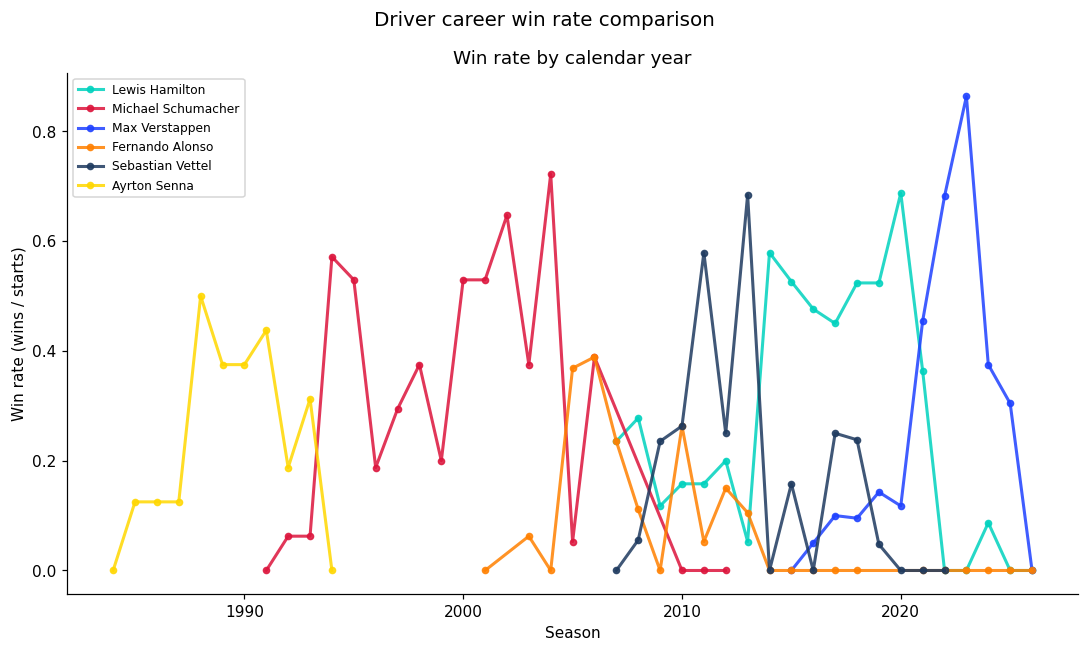

In [368]:
# Career win rate by calendar year
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Driver career win rate comparison', fontsize=13)

for drv in LEGENDS:
    sd = season_stats[season_stats['driver'] == drv].sort_values('year')
    c  = COLORS_DRV[drv]
    ax.plot(sd['year'], sd['win_rate'], 'o-', label=drv,
            color=c, linewidth=2, markersize=4, alpha=0.85)

ax.set_title('Win rate by calendar year')
ax.set_xlabel('Season')
ax.set_ylabel('Win rate (wins / starts)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


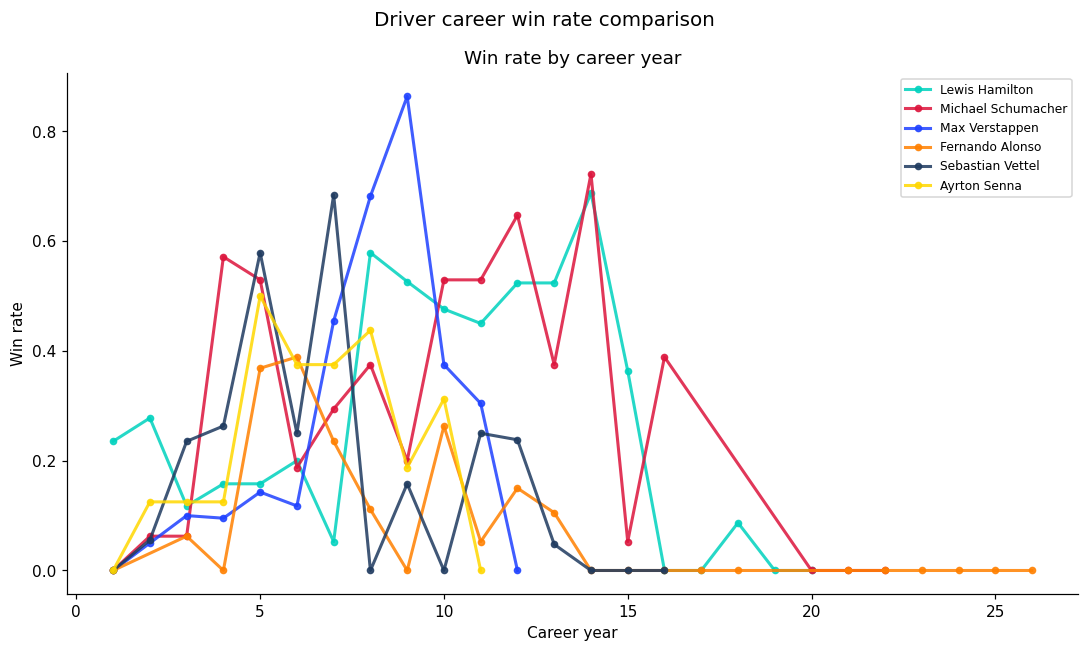

Best 3-consecutive-season average win rate:
  Lewis Hamilton        : 57.8%  (peak starting 2018)
  Michael Schumacher    : 58.1%  (peak starting 2002)
  Max Verstappen        : 66.7%  (peak starting 2021)
  Fernando Alonso       : 33.1%  (peak starting 2005)
  Sebastian Vettel      : 50.4%  (peak starting 2011)
  Ayrton Senna          : 41.7%  (peak starting 1988)


In [369]:
# Career win rate by career year
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Driver career win rate comparison', fontsize=13)

for drv in LEGENDS:
    sd = season_stats[season_stats['driver'] == drv].sort_values('year')
    c  = COLORS_DRV[drv]
    ax.plot(sd['career_year'], sd['win_rate'], 'o-', label=drv,
            color=c, linewidth=2, markersize=4, alpha=0.85)

ax.set_title('Win rate by career year')
ax.set_xlabel('Career year')
ax.set_ylabel('Win rate')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Best 3-season peak
print("Best 3-consecutive-season average win rate:")
for drv in LEGENDS:
    ss = season_stats[season_stats['driver'] == drv].sort_values('year').reset_index(drop=True)
    if len(ss) < 3:
        continue
    best_avg = 0
    best_year = 0
    for i in range(len(ss) - 2):
        avg = ss.loc[i:i+2, 'win_rate'].mean()
        if avg > best_avg:
            best_avg = avg
            best_year = int(ss.loc[i, 'year'])
    print(f"  {drv:<22}: {best_avg:.1%}  (peak starting {best_year})")


---
## 9. DNF breakdown — why do drivers not finish? <a id='dnf'></a>

**Question:** What are the most common reasons for a DNF, and how have crash-related DNFs changed over the decades?

**Background — what is a DNF?** **DNF stands for Did Not Finish**. It is recorded whenever a driver has to stop the car and retire from the race before the chequered flag. DNFs can happen for many reasons: an engine failure, a gearbox breaking, a tyre blowing out, a crash with another car, a driver error that puts the car off the track, or even a collision on the first lap. Historically, DNFs were *very* common — in the 1950s and 1960s it was not unusual for half the field to retire before the end. Today, modern engineering and tighter safety standards mean DNFs are far rarer.

We split every recorded DNF into four buckets and then track **accidents and collisions** over time. F1 has become much safer: the 1994 San Marino GP (where three-time World Champion Ayrton Senna died following a crash) was a turning point that led to a wholesale rethink of circuit safety barriers, car structures, and medical procedures. More recently, the **Halo** — a titanium hoop fitted around the driver's head since 2018 — has prevented several potentially fatal accidents.


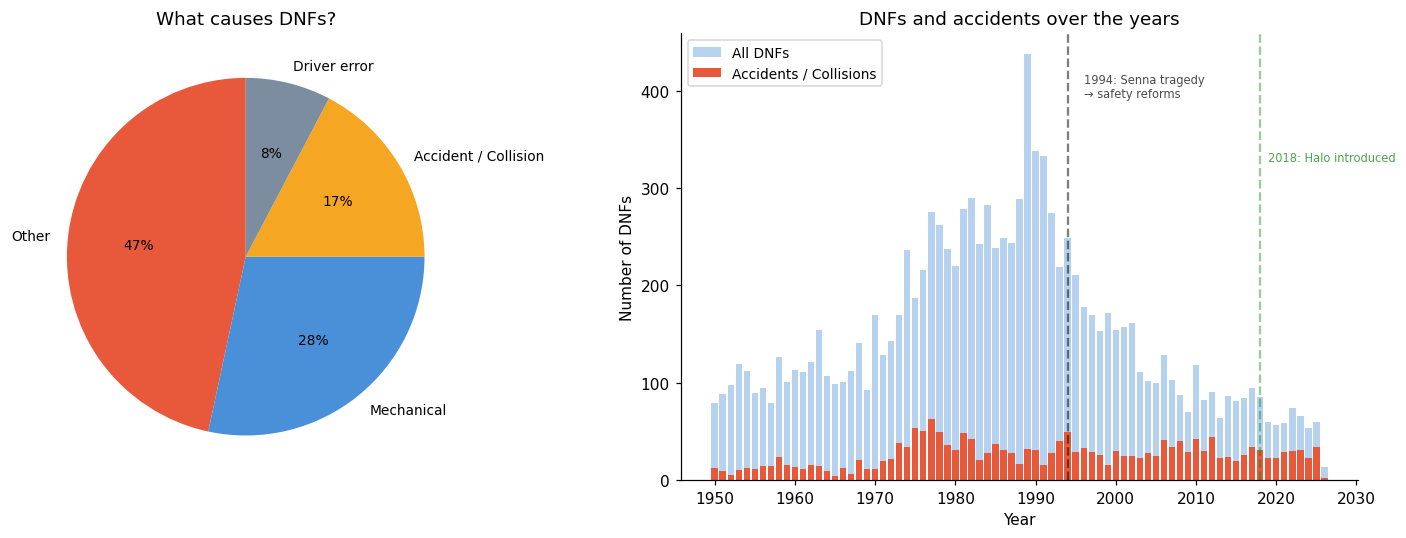

Total DNFs: 11,632
Accidents / Collisions: 2,011 (17.3%)

Top 5 DNF reasons:
status
Engine             2022
Accident           1072
Did not qualify    1024
Collision           865
Gearbox             813
Name: count, dtype: int64


In [370]:
# Focus on DNFs only — rebuild from source tables
dnf_data = results[['raceId', 'driverId', 'statusId']].copy()
dnf_data = dnf_data.merge(races[['raceId', 'year']], on='raceId')
dnf_data = dnf_data.merge(status[['statusId', 'status']], on='statusId')

# A DNF is when the driver didn't finish and wasn't just lapped
lapped   = dnf_data['status'].str.startswith('+', na=False)
finished = dnf_data['statusId'] == 1
dnf_data = dnf_data[~(finished | lapped)].copy()

# Bucket DNF reasons into simple groups
def bucket_dnf(s):
    if pd.isna(s): return 'Other'
    s = str(s).lower()
    if 'accident' in s or 'collision' in s or 'crash' in s:
        return 'Accident / Collision'
    elif 'engine' in s or 'gearbox' in s or 'transmission' in s or 'hydraulics' in s:
        return 'Mechanical'
    elif 'spun' in s or 'off track' in s or 'retired' in s:
        return 'Driver error'
    else:
        return 'Other'

dnf_data['reason'] = dnf_data['status'].apply(bucket_dnf)

# --- Pie chart of DNF buckets ---
counts = dnf_data['reason'].value_counts()
colors = ['#E8593C', '#4A90D9', '#F5A623', '#7B8D9E']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(counts, labels=counts.index, autopct='%1.0f%%', colors=colors[:len(counts)],
        startangle=90, textprops={'fontsize': 9})
ax1.set_title('What causes DNFs?')

# --- Bar chart: accidents over the years ---
accidents = dnf_data[dnf_data['reason'] == 'Accident / Collision']
acc_per_year = accidents.groupby('year').size()
dnf_per_year = dnf_data.groupby('year').size()

ax2.bar(dnf_per_year.index, dnf_per_year.values, color='#4A90D9', alpha=0.4, label='All DNFs')
ax2.bar(acc_per_year.index, acc_per_year.values, color='#E8593C', label='Accidents / Collisions')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of DNFs')
ax2.set_title('DNFs and accidents over the years')
ax2.legend(fontsize=9)

# Mark key safety milestones
y_top = float(max(dnf_per_year.max(), acc_per_year.max()))
ax2.axvline(1994, color='black', linestyle='--', alpha=0.5)
ax2.annotate('1994: Senna tragedy\n→ safety reforms', xy=(1996, y_top * 0.9),
             fontsize=7.5, alpha=0.7)
ax2.axvline(2018, color='green', linestyle='--', alpha=0.4)
ax2.annotate('2018: Halo introduced', xy=(2019, y_top * 0.75),
             fontsize=7.5, alpha=0.7, color='green')

fig.tight_layout()
plt.show()

# Quick summary
total = len(dnf_data)
acc_count = len(accidents)
print(f'Total DNFs: {total:,}')
print(f'Accidents / Collisions: {acc_count:,} ({acc_count/total*100:.1f}%)')
print('\nTop 5 DNF reasons:')
print(dnf_data['status'].value_counts().head())


---
## 10. Summary <a id='summary'></a>

| Section | Method | Key finding |
|---------|--------|-------------|
| 3. Pit stop strategy | Bar chart | 2-stop strategy shows the best average position gain; 1-stop tends to lose places on average because older tyres slow the car down relative to competitors on fresher rubber. |
| 4. Circuit clustering | KMeans (k=2) | Circuits fall into 2 groups based on pit stops, overtaking difficulty, and DNF rate. |
| 5. Grid vs finish | Pearson correlation + bar charts | r ≈ 0.45 overall — a moderate effect. Correlation has *increased* over modern eras, meaning qualifying now predicts the race result more reliably than it did in the 1960s–70s. Starting P1–3 gives a 40–50% podium rate; starting P16+ gives less than 5%. |
| 6. Race result predictor | Decision Tree | Achieves ~55–60% accuracy, only marginally better than the grid-position baseline. The small gap reveals how much of a race outcome depends on unpredictable in-race events. |
| 7. Constructor standings | Line chart (time series) | McLaren led in the early 1990s; Ferrari dominated 2000–2004; Red Bull 2010–2013; Mercedes produced an unprecedented 8-year streak 2014–2021; Red Bull surged again from 2022. |
| 8. Driver careers | Win rate + line charts | Verstappen's 2021–2023 peak win rate is the highest 3-season stretch on record. Hamilton is the most consistent top performer over the longest period. Win rate reveals peak dominance that raw win counts obscure. |
| 9. DNF breakdown | Pie chart + annotated bar chart | Mechanical failures cause the most DNFs overall. Accident rates and total retirements dropped dramatically after the 1994 safety reforms and continued to fall after the 2018 Halo introduction. |

*Dataset: [Kaggle F1 Race Data (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)*
